# Quora Duplicate Question Detection

## Project Objective

The goal of this project is to determine whether two Quora questions have the same meaning.

This is a binary classification task:

- `1` — the questions are duplicates
- `0` — the questions are not duplicates

The primary evaluation metric is **F1-score**, as it provides a balance between precision and recall and allows all evaluated approaches to be compared consistently.

Additional metrics include accuracy, precision, recall, and the confusion matrix. Log Loss is reported only for probabilistic models. It is not calculated for the BERT cosine-similarity approach because cosine similarity is not a calibrated probability.

## Data Preparation and Exploratory Data Analysis

## Project Setup and Imports

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: g:\My Drive\ML Projects\quora-duplicate-question-detection


In [3]:
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from src.config import (
    train_file,
    test_file,
    tfidf_save_path,
    processed_train_file,
    processed_test_file,
)
from src import preprocessing as prep
import matplotlib.pyplot as plt
import pickle

import re
from collections import Counter

from spacy.lang.en.stop_words import STOP_WORDS

In [4]:
RANDOMSEED = 42

In [5]:
try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    pass

## Data Loading

In [5]:
df = pd.read_csv(train_file)
pd.set_option("display.max_colwidth", None)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three independent variables is also independent?,0
1,196656,297402,297403,What is practical management and what is strategic management?,What are the practical aspects of strategic management?,0
2,113125,184949,184950,How useful is MakeUseOf Answers?,"Is there any Q&A site that is not Yahoo answers, where hate speech is allowed?",0
3,266232,101283,163744,Which is the best place to reside in India and Why?,Which ia the best place to visit in India?,0
4,122738,17811,27517,Why do so many people ask questions on Quora that can be easily answered by any number of legitimate sources on the Web? Have they not heard of Google or Bing?,Why don't many people posting questions on Quora check Google first?,1


In [6]:
df_test = pd.read_csv(test_file)
df_test.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,305985,429434,429435,Why is beef banned in India and not pork as well?,Is beef banned in india?,0
1,5193,10230,10231,At what valuation did Homejoy raise money in December of 2013?,"Should a wealthy founder self-fund his second startup then raise money at high valuation after getting traction, or raise money at low valuation before any traction?",0
2,123326,199422,199423,How do we judge?,How do I judge my love?,0
3,368557,327674,498931,Are Adderall and meth the same?,Are concerta and meth test the same?,0
4,369226,499645,499646,"If you had internet access to only one site for the rest of your life, which site would you pick?",Why is there .co.uk for British internet sites but only .fr for French ones?,0


## Exploratory Data Analysis

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 323432 entries, 0 to 323431
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            323432 non-null  int64
 1   qid1          323432 non-null  int64
 2   qid2          323432 non-null  int64
 3   question1     323431 non-null  str  
 4   question2     323430 non-null  str  
 5   is_duplicate  323432 non-null  int64
dtypes: int64(4), str(2)
memory usage: 51.8 MB


In [8]:
df.shape

(323432, 6)

In [9]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [10]:
df_test.isnull().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [11]:
df[df["question1"].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
31456,363362,493340,493341,NaN,My Chinese name is Haichao Yu. What English name is most suitable for me considering the pronounciation of my Chinese name?,0


In [12]:
df[df["question2"].isna()]

,id,qid1,qid2,question1,question2,is_duplicate
58432,201841,303951,174364,How can I create an Android app?,NaN,0
210927,105780,174363,174364,How can I develop android app?,NaN,0


**Dropping entries with missing values**

In [13]:
df.dropna(subset=["question1", "question2"], inplace=True)
df.reset_index(drop=True, inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df_test.duplicated().sum()

np.int64(0)

In [16]:
((df["question1"].str.strip() == "") |
 (df["question2"].str.strip() == "")).sum()

np.int64(0)

In [17]:
((df_test["question1"].str.strip() == "") |
 (df_test["question2"].str.strip() == "")).sum()

np.int64(0)

In [18]:
print("Train:")
print("Rows:", len(df))
print("ID unique:", df["id"].is_unique)
print("Missing ID:", df["id"].isna().sum())

print("\nTest:")
print("Rows:", len(df_test))
print("ID unique:", df_test["id"].is_unique)
print("Missing ID:", df_test["id"].isna().sum())

Train:
Rows: 323429
ID unique: True
Missing ID: 0

Test:
Rows: 80858
ID unique: True
Missing ID: 0


No fully duplicated rows or empty question strings were found.

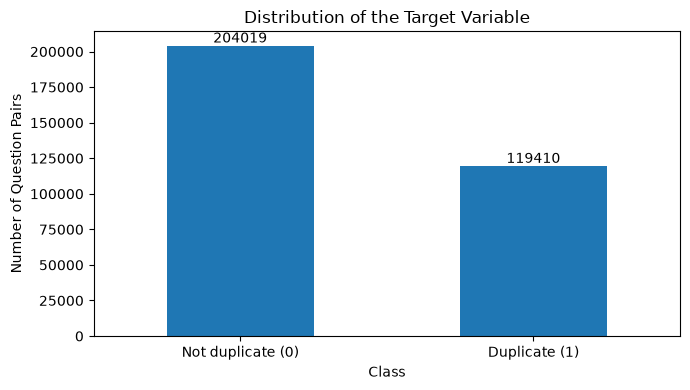

In [19]:
target_distribution = (
    df["is_duplicate"]
    .value_counts()
    .sort_index()
)

ax = target_distribution.plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("Distribution of the Target Variable")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Question Pairs")
ax.set_xticklabels(
    ["Not duplicate (0)", "Duplicate (1)"],
    rotation=0,
)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

The target variable is moderately imbalanced: non-duplicate question pairs
represent the majority class, while duplicate pairs account for approximately
37% of the training dataset.

In [20]:
questions = pd.concat([df["question1"], df["question2"]], ignore_index=True)
all_question_lengths = questions.str.len()
all_question_lengths.describe()

count    646858.000000
mean         59.827502
std          31.968420
min           1.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1169.000000
dtype: float64

In [21]:
all_question_lengths.quantile([0.95, 0.99, 0.999])

0.950    125.000
0.990    156.000
0.999    270.143
dtype: float64

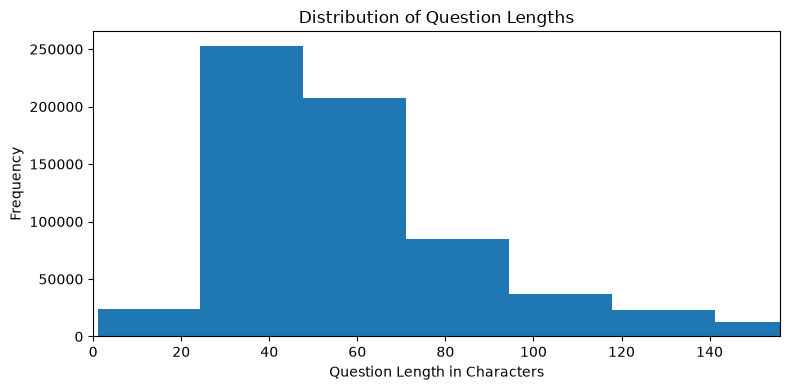

In [22]:
all_question_lengths.plot(
    kind="hist",
    bins=50,
    figsize=(8, 4)
)

plt.title("Distribution of Question Lengths")
plt.xlabel("Question Length in Characters")
plt.ylabel("Frequency")
plt.xlim(0, all_question_lengths.quantile(0.99))
plt.tight_layout()
plt.show()

The distribution is right-skewed: most questions are relatively short: the mean length is about 60 characters,
99% of questions are shorter than 156 characters, and 99.9% are shorter than
approximately 270 characters. The x-axis is limited to
the 99th percentile to make the main part of the distribution easier to see.

### Inspection of Long Questions

The question-length distribution contains a small number of unusually long
observations. The longest questions are inspected manually to determine
whether they represent valid text or corrupted data.

In [23]:
longest_questions = (
    questions
    .drop_duplicates()
    .sort_values(key=lambda x: x.str.len(), ascending=False)
    .head(10)
    .to_frame(name="question")
)

longest_questions["length"] = longest_questions["question"].str.len()

display(longest_questions)

,question,length
375509,"I have been married almost 15 years. We have two children, 11 and 8. My childhood was horrible, seven years of sexual, physical, and mental/emotional abuse followed by instability and low self esteem issues as a teen. My husband met me after I began dealing with my childhood and knew all about my issues. He knew what would end our marriage, yet he did it and lied about it multiple times. I was pregnant and did not leave. We tried to make it work. We had another child. We have been through MANY ""situations"" in our marriage and as parents. For the past 6-8 years we have just been living as parents. Not lovers. In the past I tried everything to make our marriage work. I finally decided to be done with it. Now he says he loves me and wants to make it work. But he is manipulative and can be so mean. He uses my children to cause me pain and stress. He knows that they are the only reason I stay. We are in counciling, but I really have no ""love"" feelings for him. I told him I want a divorce, but he won't give me one. He has said he will make my life miserable until the 18 months of separation are up and divorce is granted. Any advice? I'm ready to run away...",1169
363927,"Heartbreak? Heartbreak? She's my girlfriend for two months, I chose her over my girlfriend for 2 years. I like her so much to the point that I can't let her go even if she wants to end our relationship because of the other people around us most especially her family. I do the things for her that I'm not used to for a girl and I am willing to sacrifice everything just to have a little time with her. A little and limited time that I'm asking from her but she don't wanna give it to me. She's scared that someone might see us, that she's still having an affair with me. I love her and I want to be with her at least once a week even if just for a limited time. I'm not sure if I'm doing the right thing, all of my friends told me to stop it and just let it go 2 months is just 2 months not a deep relationship. But they don't feel what I feel, in this span of time I learned a lot, I learned how to love, to be loved, to sacrifice a good life, and to sacrifice a better clear future. My mind tells me to stop, but my heart tells me to hold, don't give up, stay with her and give her the unconditional love. Should I follow my mind or follow my heart?",1151
464945,"Regarding Google Plus Profile Privacy Settings: Here's the scenario: An individual finds my Google Plus page. They go to my profile. They take a screen shot of it. The screen shot includes a portion which reads, ""Other Names"" below which is a name, below which are the words, ""Visible Only To You"" below which are ""Google Contact Details"" below which appear again, Visible Only To You."" The screen shot was then printed and presented to a third party as evidence of my so-called ""other name."" I logged in and saw the name, this time with the privacy settings set to Public but this profile defaults to ""only you"" so it had been changed. These changes to my profile were not made by me. Does the screenshot that was taken then printed mean the party taking it was actually logged in as me. Or is there another explanation?",823
641623,"Whole fight card for UFC on Fuel TV 9, 6th April in Stockholm, Sweden? I've been looking around for the card for this upcoming event, but I can't find more than three fights. More isn't listed at UFC's site so I presume that the card isn't finished yet? But are there any rumors or any other things that indicate which fighters may participate? I had the best seats in the house money can buy last year and planning to buy the same again tomorrow when the pre sale starts (in exactly 13h from now). But I don't want to pay $375 USD if the only good fight is the main event (Alexander Gustafsson FTW!)... All information/rumours/indications is appreciated ASAP so I can decide how much money I'm willing to pay for the tickets?",727
344973,"This question is stirred up by the 

The longest questions were checked manually. They contain valid text, so they were kept in the dataset.

### Vocabulary Size and Frequent Words

To better understand the vocabulary of the dataset, the questions are converted
to lowercase and split into alphabetic tokens. Vocabulary size is calculated
using all tokens, while English stop words are excluded from the frequency plot
to make the result more informative.

In [24]:
token_pattern = re.compile(r"[a-z]+(?:'[a-z]+)?")

token_counts = Counter(
    token
    for question in questions.str.lower()
    for token in token_pattern.findall(question)
)

print(f"Vocabulary size: {len(token_counts):,}")
print(f"Total number of tokens: {sum(token_counts.values()):,}")

Vocabulary size: 74,926
Total number of tokens: 7,123,550


In [25]:
content_word_counts = {
    word: count
    for word, count in token_counts.items()
    if word not in STOP_WORDS and len(word) > 1
}

top_words = (
    pd.Series(content_word_counts, name="frequency")
    .nlargest(15)
    .sort_values()
)

top_words.sort_values(ascending=False).to_frame()

,frequency
best,56499
india,23210
people,20955
like,20499
good,19997
way,14452
quora,14400
life,13072
time,12105
money,11640


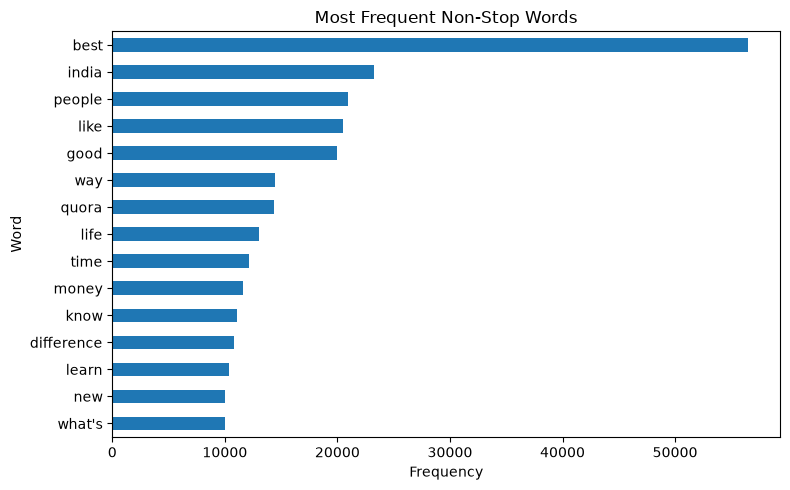

In [26]:
ax = top_words.plot(
    kind="barh",
    figsize=(8, 5),
)

ax.set_title("Most Frequent Non-Stop Words")
ax.set_xlabel("Frequency")
ax.set_ylabel("Word")

plt.tight_layout()
plt.show()

The most frequent word is "best". Other common words include "India", "people", "good", "way", and "Quora".

These words reflect common topics and question formats in the dataset.

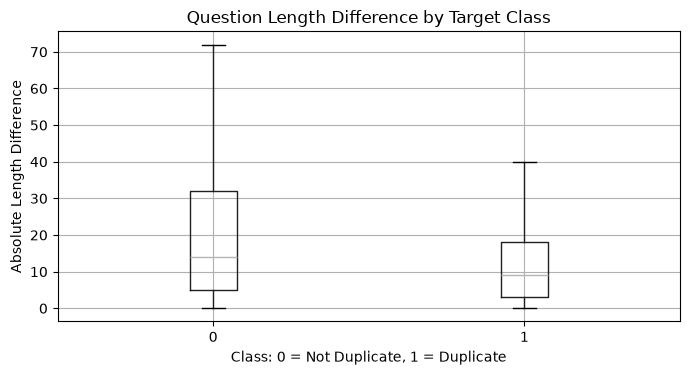

In [22]:
length_comparison = pd.DataFrame(
    {
        "is_duplicate": df["is_duplicate"],
        "length_difference": (
            df["question1"].str.len()
            - df["question2"].str.len()
        ).abs(),
    }
)

length_comparison.boxplot(
    column="length_difference",
    by="is_duplicate",
    figsize=(7, 4),
    showfliers=False,
)

plt.title("Question Length Difference by Target Class")
plt.suptitle("")
plt.xlabel("Class: 0 = Not Duplicate, 1 = Duplicate")
plt.ylabel("Absolute Length Difference")
plt.tight_layout()
plt.show()

Duplicate question pairs generally have a smaller absolute difference in
question length. Their median length difference and interquartile range are
lower than those of non-duplicate pairs.
It may serve as a useful feature when combined with other lexical and similarity
features in a boosting model.

In [23]:
print("Number of unique questions:", questions.nunique())

Number of unique questions: 449361


In [24]:
print("Number of all questions: ", questions.shape[0])

Number of all questions:  646858


### EDA Summary

The dataset contains more non-duplicate pairs than duplicate pairs, so stratified splitting will be used.

Most questions are relatively short, although a small number of valid long questions are present. Duplicate pairs also tend to have a smaller difference in question length.

## Data Split

In [ ]:
X = df.drop(columns=["is_duplicate"])
y = df['is_duplicate']

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify = y,
                                                  random_state=RANDOMSEED)

In [24]:
df["split"] = pd.NA

train_ids = X_train["id"]
valid_ids = X_valid["id"]

df.loc[df["id"].isin(train_ids), "split"] = "train"
df.loc[df["id"].isin(valid_ids), "split"] = "valid"

In [25]:
assert df["split"].notna().all()
assert df["id"].is_unique

print(df["split"].value_counts())
print()

print(
    df.groupby("split")["is_duplicate"]
    .value_counts(normalize=True)
    .unstack()
)

split
train    258743
valid     64686
Name: count, dtype: int64

is_duplicate         0         1
split                           
train         0.630800  0.369200
valid         0.630801  0.369199


In [23]:
X_test = df_test.drop(columns=["is_duplicate"])
y_test = df_test['is_duplicate']

## Text Preprocessing and TF-IDF

### TF-IDF text map creation

The cells below create and save the processed text mapping.
They should only be executed when the saved mapping does not exist
or when the preprocessing logic has changed.

In [29]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

In [38]:
unique_questions = prep.collect_unique_questions(
    X_train,
    X_valid,
    X_test
)

In [39]:
basic_tfidf_texts = unique_questions.apply(
    prep.prepare_text_for_tfidf
)

In [ ]:
processed_tfidf_texts = []

docs = nlp.pipe(
    basic_tfidf_texts,
    batch_size=1000,
    n_process=1
)

for doc in tqdm(
    docs,
    total=len(basic_tfidf_texts)
):
    processed_tfidf_texts.append(
        prep.process_spacy_doc(doc)
    )

In [ ]:
tfidf_text_map = dict(
    zip(unique_questions, processed_tfidf_texts)
)

print(f"Processed questions: {len(tfidf_text_map):,}")

Processed questions: 537,359


In [ ]:
with open(tfidf_save_path, "wb") as f:
    pickle.dump(tfidf_text_map, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved to: {tfidf_save_path}")

Saved to: /content/drive/MyDrive/ML Projects/Quora duplicates/embeddings/tfidf_text_map_v1.pkl


### Load TF-IDF texts and add them as features to datasets

In [41]:
with open(tfidf_save_path, "rb") as f:
    tfidf_text_map = pickle.load(f)

print(f"Loaded processed questions: {len(tfidf_text_map):,}")

Loaded processed questions: 537,359


In [43]:
X_train["question1_tfidf"] = (
    X_train["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_train["question2_tfidf"] = (
    X_train["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_valid["question1_tfidf"] = (
    X_valid["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_valid["question2_tfidf"] = (
    X_valid["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_test["question1_tfidf"] = (
    X_test["question1"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

X_test["question2_tfidf"] = (
    X_test["question2"]
    .fillna("")
    .astype(str)
    .map(tfidf_text_map)
)

In [44]:
text_columns = [
    "question1_tfidf",
    "question2_tfidf"
]

for column in text_columns:
    print(
        column,
        "train empty:",
        X_train[column].fillna("").str.strip().eq("").sum(),
        "val empty:",
        X_valid[column].fillna("").str.strip().eq("").sum()
    )

question1_tfidf train empty: 7 val empty: 4
question2_tfidf train empty: 4 val empty: 1


### Text normalization for manual feature engineering

Create lightly normalized versions of both questions for future handcrafted
feature engineering and boosting models.

The preprocessing converts text to lowercase, removes HTML tags and normalizes
whitespace, while preserving stop words, punctuation and numbers.

These columns are not used in the TF-IDF Logistic Regression experiment.

An initial preprocessing pipeline included stop-word removal. After inspecting the processed texts, it became clear that this step removed all informative tokens from some valid questions (e.g., "Who am I?", "How is everyone?", "Why did you give up?"), resulting in empty documents. Since interrogative words and auxiliary verbs carry important semantic information in question-pair similarity tasks, stop-word removal was excluded from the final pipeline. After this revision, only questions consisting entirely of punctuation or other non-lexical characters remained empty. These samples were retained, as TF-IDF naturally represents them as zero vectors without affecting the preprocessing pipeline.

In [ ]:
for X in [X_train, X_valid, X_test]:
    X["question1_features"] = (
        X["question1"]
        .apply(prep.prepare_text_for_features)
    )

    X["question2_features"] = (
        X["question2"]
        .apply(prep.prepare_text_for_features)
    )

## Save Preprocessed Datasets

Combine the predefined train and validation subsets, preserve the stable
original `id`, and save the processed train and test datasets in Parquet format.

In [45]:
base_columns = [
    "id",
    "qid1",
    "qid2",
    "question1",
    "question2",
]

processed_text_columns = [
    "question1_tfidf",
    "question2_tfidf",
    "question1_features",
    "question2_features",
]

processed_train = pd.concat(
    [
        X_train.assign(
            is_duplicate=y_train,
            split="train",
        ),
        X_valid.assign(
            is_duplicate=y_valid,
            split="valid",
        ),
    ],
    axis=0,
).sort_index()

processed_test = (
    X_test.assign(is_duplicate=y_test)
    .sort_index()
)

processed_train = processed_train[
    base_columns
    + ["is_duplicate", "split"]
    + processed_text_columns
].reset_index(drop=True)

processed_test = processed_test[
    base_columns
    + ["is_duplicate"]
    + processed_text_columns
].reset_index(drop=True)

In [ ]:
Path(processed_train_file).parent.mkdir(
    parents=True,
    exist_ok=True,
)

processed_train.to_parquet(
    processed_train_file,
    index=False,
)

processed_test.to_parquet(
    processed_test_file,
    index=False,
)

print("Saved train dataset:")
print(processed_train_file)

print("\nSaved test dataset:")
print(processed_test_file)